# 12 — Statistical Significance Testing (Paired, Across LOSO Folds)
**Project:** Quantum Machine Learning for Physiological Stress Classification
**Author:** Kenza Qribis

---

## Purpose
Test whether the F1 differences between models are statistically significant, not
just numerically different — paired across LOSO folds, since every model sees the
same held-out subject in each fold.

## Inputs
- `classical_baselines_full_per_fold.csv` — from `05b_classical_baselines_full.ipynb`
  (full-data classical: Logistic Regression, SVM RBF, Random Forest)
- `cnn_baseline_per_fold.csv` — from `06_cnn_baseline.ipynb` (1D-CNN)
- `hybrid_cnn_qnn_per_fold.csv` — from `09_hybrid_cnn_qnn.ipynb` (Hybrid CNN-QNN)

All three are LOSO per-fold results keyed by `test_subject`, which is what makes a
**paired** test valid here: fold *i* in every file is the same held-out subject, so
we're comparing matched observations, not independent samples.

Note: this compares against the **full-data** classical run (`05b`), not the
subsampled one in `05` — 05b's numbers are the fair comparison point against
CNN/hybrid, since both were trained on full data.

## Method
- **Primary test:** Wilcoxon signed-rank test (paired, non-parametric) — appropriate
  given the small number of folds (15 WESAD subjects, ~22 DREAMER subjects) and no
  assumption that F1 differences are normally distributed.
- **Secondary test:** paired t-test, reported alongside for reference.
- **Effect size:** matched-pairs rank-biserial correlation (for Wilcoxon) and Cohen's
  d for paired samples (for the t-test).
- **Multiple comparisons:** every pair of models within a task is tested, so p-values
  are corrected with Holm-Bonferroni *within each task's family of tests*.

## Output
- `results/output_data/significance_tests.csv` — one row per (task, model A, model B)
- `results/plots/12_significance_testing/*.png` — per-task F1 boxplots with
  significance annotations


## 0. Configuration

In [1]:
import os, json, re, itertools, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

RESULTS_ROOT    = os.path.join('..', 'results')
PLOTS_DIR       = os.path.join(RESULTS_ROOT, 'plots', '12_significance_testing')
OUTPUT_DATA_DIR = os.path.join(RESULTS_ROOT, 'output_data')
os.makedirs(PLOTS_DIR, exist_ok=True)

ALPHA = 0.05

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11
sns.set_style('whitegrid')

print('Configuration ready.')
print(f'  Significance level (alpha): {ALPHA}')
print(f'  Plots dir: {os.path.abspath(PLOTS_DIR)}')


Configuration ready.
  Significance level (alpha): 0.05
  Plots dir: c:\Users\vPro\OneDrive\Desktop\kenza\research\Applied-Research\results\plots\12_significance_testing


## 1. Load Per-Fold Results
The three source files use different task-name suffixes (`_CNN`, `_Hybrid`, none for
classical) — normalize them to a shared task name before anything else, or the merge
below silently drops every row.

In [ ]:
classical_path = os.path.join(OUTPUT_DATA_DIR, 'classical_baselines_full_per_fold.csv')
cnn_path       = os.path.join(OUTPUT_DATA_DIR, 'cnn_baseline_per_fold.csv')
hybrid_path    = os.path.join(OUTPUT_DATA_DIR, 'hybrid_cnn_qnn_per_fold.csv')

missing = [p for p in [classical_path, cnn_path, hybrid_path] if not os.path.exists(p)]
if missing:
    raise FileNotFoundError(
        'Missing required per-fold result files:\n  ' + '\n  '.join(missing) +
        '\n\nRun 05b_classical_baselines_full.ipynb, 06_cnn_baseline_PATCHED.ipynb and '
        '09_hybrid_cnn_qnn.ipynb first.'
    )

df_classical = pd.read_csv(classical_path)
df_cnn       = pd.read_csv(cnn_path)
df_hybrid    = pd.read_csv(hybrid_path)

def normalize_task(t):
    return re.sub(r'_(CNN|Hybrid)$', '', str(t))

for df in (df_classical, df_cnn, df_hybrid):
    df['task_canonical'] = df['task'].apply(normalize_task)

keep_cols = ['task_canonical', 'model', 'test_subject', 'f1', 'accuracy']
df_long = pd.concat([
    df_classical[keep_cols],
    df_cnn[keep_cols],
    df_hybrid[keep_cols],
], ignore_index=True)

print('=== Models available per task ===')
print(df_long.groupby('task_canonical')['model'].unique().to_string())
print(f'\nTotal rows: {len(df_long)}')


=== Models available per task ===
task_canonical
DREAMER_binary_EEG    [Logistic Regression, SVM (RBF), Random Forest...
WESAD_3class          [Logistic Regression, SVM (RBF), Random Forest...
WESAD_binary          [Logistic Regression, SVM (RBF), Random Forest...

Total rows: 242


## 2. Paired Test Utilities

In [3]:
def paired_effect_size_wilcoxon(diffs):
    """Matched-pairs rank-biserial correlation for the Wilcoxon signed-rank test."""
    diffs = np.asarray(diffs)
    diffs = diffs[diffs != 0]
    if len(diffs) == 0:
        return np.nan
    ranks = stats.rankdata(np.abs(diffs))
    pos = ranks[diffs > 0].sum()
    neg = ranks[diffs < 0].sum()
    total = pos + neg
    return (pos - neg) / total if total > 0 else np.nan


def cohens_d_paired(diffs):
    diffs = np.asarray(diffs)
    sd = diffs.std(ddof=1)
    return diffs.mean() / sd if sd > 0 else np.nan


def compare_pair(df_task, model_a, model_b, metric='f1'):
    """
    Align model_a and model_b on test_subject (inner join — only subjects present
    in BOTH models' folds are compared) and run paired Wilcoxon + paired t-test.
    """
    a = df_task[df_task['model'] == model_a][['test_subject', metric]] \
            .rename(columns={metric: 'a'})
    b = df_task[df_task['model'] == model_b][['test_subject', metric]] \
            .rename(columns={metric: 'b'})
    merged = a.merge(b, on='test_subject', how='inner').sort_values('test_subject')

    n = len(merged)
    result = {
        'model_a': model_a, 'model_b': model_b, 'n_folds': n,
        'mean_a': round(merged['a'].mean(), 4) if n else np.nan,
        'mean_b': round(merged['b'].mean(), 4) if n else np.nan,
        'mean_diff_a_minus_b': round((merged['a'] - merged['b']).mean(), 4) if n else np.nan,
        'wilcoxon_stat': np.nan, 'wilcoxon_p': np.nan, 'wilcoxon_effect_r': np.nan,
        'ttest_stat': np.nan, 'ttest_p': np.nan, 'cohens_d': np.nan,
        'note': '',
    }

    if n < 6:
        result['note'] = f'Too few paired folds (n={n}) for a reliable test — skipped.'
        return result

    diffs = (merged['a'] - merged['b']).values

    if np.all(diffs == 0):
        result['note'] = 'Identical scores on every fold — no variance to test.'
        return result

    try:
        w_stat, w_p = stats.wilcoxon(merged['a'], merged['b'])
        result['wilcoxon_stat']   = round(float(w_stat), 4)
        result['wilcoxon_p']      = float(w_p)
        result['wilcoxon_effect_r'] = round(paired_effect_size_wilcoxon(diffs), 4)
    except ValueError as e:
        result['note'] += f'Wilcoxon failed: {e}. '

    t_stat, t_p = stats.ttest_rel(merged['a'], merged['b'])
    result['ttest_stat'] = round(float(t_stat), 4)
    result['ttest_p']    = float(t_p)
    result['cohens_d']   = round(cohens_d_paired(diffs), 4)

    return result


def holm_bonferroni(pvals):
    """Holm-Bonferroni step-down correction. NaN p-values pass through as NaN."""
    pvals = np.asarray(pvals, dtype=float)
    n = np.sum(~np.isnan(pvals))
    order = np.argsort(np.where(np.isnan(pvals), np.inf, pvals))
    adjusted = np.full_like(pvals, np.nan)
    running_max = 0.0
    rank = 0
    for idx in order:
        if np.isnan(pvals[idx]):
            continue
        rank += 1
        val = min(1.0, (n - rank + 1) * pvals[idx])
        running_max = max(running_max, val)
        adjusted[idx] = running_max
    return adjusted

print('Test utilities defined.')


Test utilities defined.


## 3. Run All Pairwise Comparisons
For every task, every pair of models that has data for that task is compared,
paired on `test_subject`. This includes classical-vs-CNN, classical-vs-hybrid,
CNN-vs-hybrid, and the three classical models against each other.

In [4]:
all_rows = []

for task in sorted(df_long['task_canonical'].unique()):
    df_task = df_long[df_long['task_canonical'] == task]
    models  = sorted(df_task['model'].unique())
    print(f'\n=== {task} — {len(models)} models: {models} ===')

    task_rows = []
    for model_a, model_b in itertools.combinations(models, 2):
        row = compare_pair(df_task, model_a, model_b, metric='f1')
        row['task'] = task
        task_rows.append(row)

    # Holm-Bonferroni within this task's family of Wilcoxon tests
    wilcoxon_ps = [r['wilcoxon_p'] for r in task_rows]
    adj_ps = holm_bonferroni(wilcoxon_ps)
    for r, adj_p in zip(task_rows, adj_ps):
        r['wilcoxon_p_holm'] = round(float(adj_p), 4) if not np.isnan(adj_p) else np.nan
        r['significant_at_0.05'] = (
            bool(adj_p < ALPHA) if not np.isnan(adj_p) else False
        )

    for r in task_rows:
        marker = '*' if r.get('significant_at_0.05') else ' '
        print(f"  {marker} {r['model_a']:22s} vs {r['model_b']:22s}  "
              f"F1 diff={r['mean_diff_a_minus_b']:+.4f}  "
              f"wilcoxon p (holm)={r['wilcoxon_p_holm']}")

    all_rows.extend(task_rows)

df_sig = pd.DataFrame(all_rows)
col_order = ['task', 'model_a', 'model_b', 'n_folds', 'mean_a', 'mean_b',
             'mean_diff_a_minus_b', 'wilcoxon_stat', 'wilcoxon_p', 'wilcoxon_p_holm',
             'wilcoxon_effect_r', 'ttest_stat', 'ttest_p', 'cohens_d',
             'significant_at_0.05', 'note']
df_sig = df_sig[col_order]

p = os.path.join(OUTPUT_DATA_DIR, 'significance_tests.csv')
df_sig.to_csv(p, index=False)
print(f'\nSaved: {p}')
df_sig



=== DREAMER_binary_EEG — 4 models: ['Hybrid CNN-QNN', 'Logistic Regression', 'Random Forest', 'SVM (RBF)'] ===
    Hybrid CNN-QNN         vs Logistic Regression     F1 diff=-0.0598  wilcoxon p (holm)=1.0
    Hybrid CNN-QNN         vs Random Forest           F1 diff=-0.0376  wilcoxon p (holm)=1.0
    Hybrid CNN-QNN         vs SVM (RBF)               F1 diff=-0.0371  wilcoxon p (holm)=1.0
    Logistic Regression    vs Random Forest           F1 diff=+0.0222  wilcoxon p (holm)=1.0
    Logistic Regression    vs SVM (RBF)               F1 diff=+0.0226  wilcoxon p (holm)=1.0
    Random Forest          vs SVM (RBF)               F1 diff=+0.0005  wilcoxon p (holm)=1.0

=== WESAD_3class — 5 models: ['1D-CNN', 'Hybrid CNN-QNN', 'Logistic Regression', 'Random Forest', 'SVM (RBF)'] ===
  * 1D-CNN                 vs Hybrid CNN-QNN          F1 diff=+0.1798  wilcoxon p (holm)=0.0302
    1D-CNN                 vs Logistic Regression     F1 diff=+0.1765  wilcoxon p (holm)=0.0585
  * 1D-CNN            

,task,model_a,model_b,n_folds,mean_a,mean_b,mean_diff_a_minus_b,wilcoxon_stat,wilcoxon_p,wilcoxon_p_holm,wilcoxon_effect_r,ttest_stat,ttest_p,cohens_d,significant_at_0.05,note
0,DREAMER_binary_EEG,Hybrid CNN-QNN,Logistic Regression,23,0.4258,0.4855,-0.0598,94.0,0.189542,1.0000,-0.3188,-1.3896,0.178547,-0.2898,False,
1,DREAMER_binary_EEG,Hybrid CNN-QNN,Random Forest,23,0.4258,0.4634,-0.0376,71.0,0.204291,1.0000,-0.3238,-1.1352,0.268489,-0.2367,False,
2,DREAMER_binary_EEG,Hybrid CNN-QNN,SVM (RBF),23,0.4258,0.4629,-0.0371,80.0,0.217241,1.0000,-0.3074,-1.1884,0.247344,-0.2478,False,
3,DREAMER_binary_EEG,Logistic Regression,Random Forest,23,0.4855,0.4634,0.0222,121.0,0.622068,1.0000,0.1232,0.6386,0.529676,0.1332,False,
4,DREAMER_binary_EEG,Logistic Regression,SVM (RBF),23,0.4855,0.4629,0.0226,100.0,0.389602,1.0000,0.2095,0.7925,0.436560,0.1652,False,
5,DREAMER_binary_EEG,Random Forest,SVM (RBF),23,0.4634,0.4629,0.0005,122.0,0.883846,1.0000,-0.0356,0.0149,0.988279,0.0031,False,
6,WESAD_3class,1D-CNN,Hybrid CNN-QNN,15,0.7515,0.5716,0.1798,11.0,0.003357,0.0302,0.8167,3.6826,0.002461,0.9508,True,
7,WESAD_3class,1D-CNN,Logistic Regression,15,0.7515,0.5750,0.1765,15.0,0.008362,0.0585,0.7500,3.3132,0.005126,0.8555,False,
8,WESAD_3class,1D-CNN,Random Forest,15,0.7515,0.6130,0.1385,12.0,0.004272,0.0342,0.8000,3.3585,0.004684,0.8672,True,
9,WESAD_3class,1D-CNN,SVM (RBF),15,0.7515,0.5253,0.2262,10.0,0.002625,0.0262,0.8333,3.9871,0.001350,1.0295,True,


## 4. Focused View — Classical (Full) vs. CNN/Hybrid
The comparisons that motivated this notebook: does the best full-data classical
model differ significantly from the CNN and the hybrid CNN-QNN?

In [5]:
focus_models = {'1D-CNN', 'Hybrid CNN-QNN'}

focus = df_sig[
    df_sig['model_a'].isin(focus_models) | df_sig['model_b'].isin(focus_models)
].copy()

# also filter out cnn-vs-hybrid rows here, keep those in the full table only
focus = focus[~(focus['model_a'].isin(focus_models) & focus['model_b'].isin(focus_models))]

print('=== Classical (full data) vs. CNN / Hybrid CNN-QNN ===')
print(focus[['task', 'model_a', 'model_b', 'mean_diff_a_minus_b',
             'wilcoxon_p_holm', 'significant_at_0.05']].to_string(index=False))


=== Classical (full data) vs. CNN / Hybrid CNN-QNN ===
              task        model_a             model_b  mean_diff_a_minus_b  wilcoxon_p_holm  significant_at_0.05
DREAMER_binary_EEG Hybrid CNN-QNN Logistic Regression              -0.0598           1.0000                False
DREAMER_binary_EEG Hybrid CNN-QNN       Random Forest              -0.0376           1.0000                False
DREAMER_binary_EEG Hybrid CNN-QNN           SVM (RBF)              -0.0371           1.0000                False
      WESAD_3class         1D-CNN Logistic Regression               0.1765           0.0585                False
      WESAD_3class         1D-CNN       Random Forest               0.1385           0.0342                 True
      WESAD_3class         1D-CNN           SVM (RBF)               0.2262           0.0262                 True
      WESAD_3class Hybrid CNN-QNN Logistic Regression              -0.0034           1.0000                False
      WESAD_3class Hybrid CNN-QNN       R

## 5. Per-Task F1 Boxplots with Significance Annotations

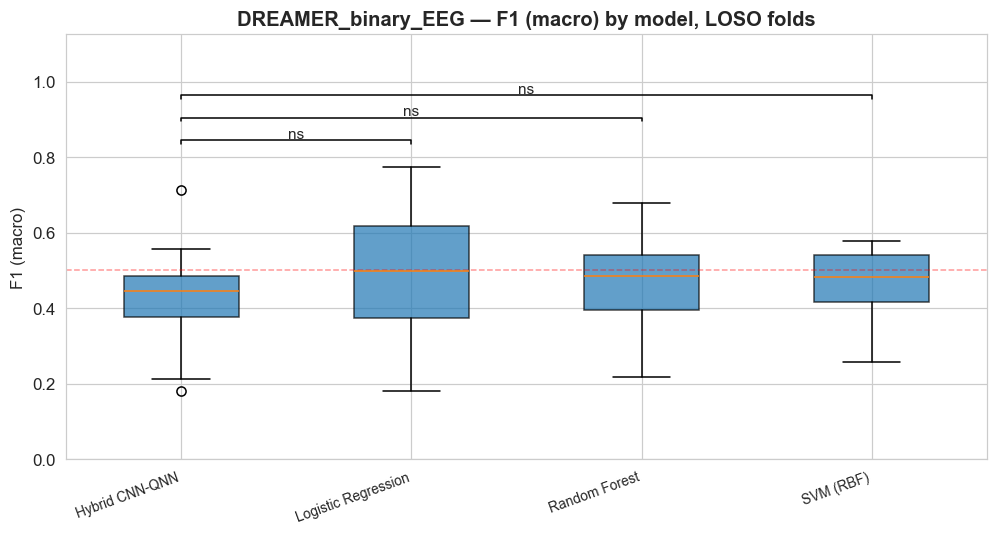

Saved: ..\results\plots\12_significance_testing\DREAMER_binary_EEG_f1_significance.png


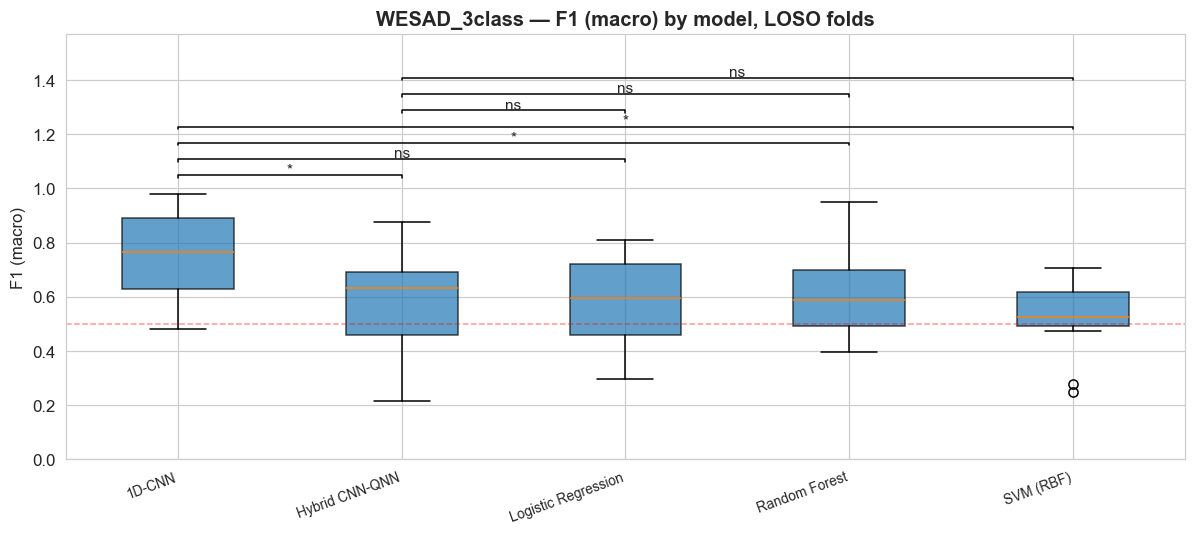

Saved: ..\results\plots\12_significance_testing\WESAD_3class_f1_significance.png


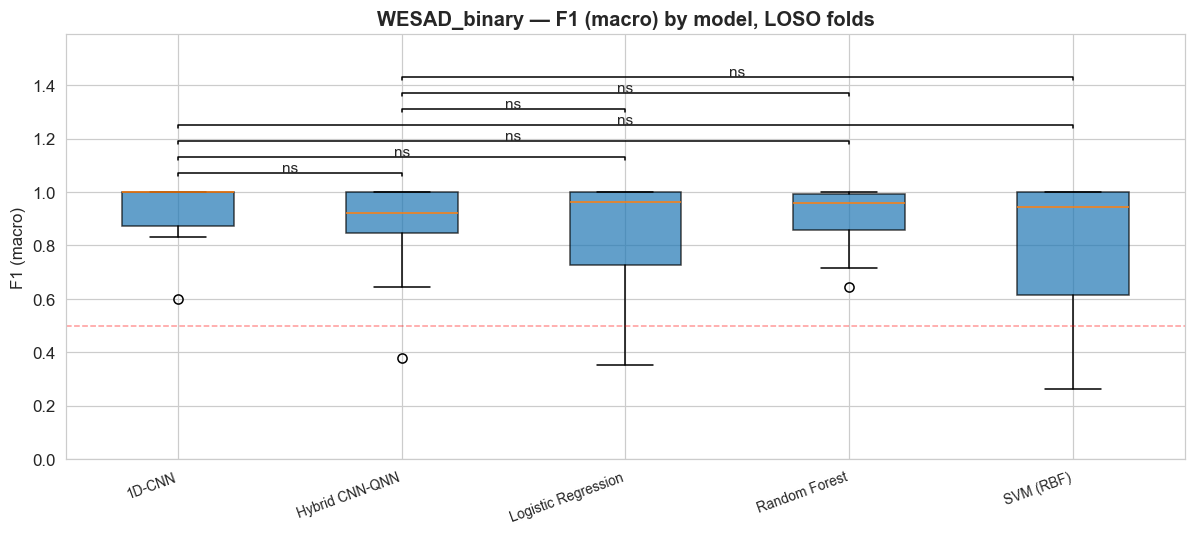

Saved: ..\results\plots\12_significance_testing\WESAD_binary_f1_significance.png


In [6]:
def stars_for_p(p):
    if pd.isna(p):
        return 'n/a'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

for task in sorted(df_long['task_canonical'].unique()):
    df_task = df_long[df_long['task_canonical'] == task]
    models  = sorted(df_task['model'].unique())
    data    = [df_task[df_task['model'] == m]['f1'].values for m in models]

    fig, ax = plt.subplots(figsize=(1.8 * len(models) + 2, 5))
    bp = ax.boxplot(data, patch_artist=True, labels=models, widths=0.5)
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax.set_title(f'{task} — F1 (macro) by model, LOSO folds', fontweight='bold')
    ax.set_ylabel('F1 (macro)')
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.axhline(0.5, color='red', linestyle='--', lw=1, alpha=0.4)

    # annotate involving the CNN/hybrid comparisons only, to avoid a forest of lines
    task_sig = df_sig[
        (df_sig['task'] == task) &
        (df_sig['model_a'].isin(focus_models) | df_sig['model_b'].isin(focus_models))
    ]
    y_top = max(d.max() if len(d) else 0 for d in data) if data else 1.0
    step = 0.06
    for i, (_, r) in enumerate(task_sig.iterrows()):
        if r['model_a'] not in models or r['model_b'] not in models:
            continue
        xa = models.index(r['model_a']) + 1
        xb = models.index(r['model_b']) + 1
        y = y_top + step * (i + 1)
        ax.plot([xa, xa, xb, xb], [y, y + 0.01, y + 0.01, y], color='black', lw=1)
        ax.text((xa + xb) / 2, y + 0.015, stars_for_p(r['wilcoxon_p_holm']),
                ha='center', fontsize=10)
    ax.set_ylim(0, y_top + step * (len(task_sig) + 2) + 0.05)

    plt.tight_layout()
    fname = os.path.join(PLOTS_DIR, f'{task}_f1_significance.png')
    plt.savefig(fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')


## 6. Summary Log

In [7]:
summary_dict = {
    'notebook'  : '12_significance_testing',
    'timestamp' : pd.Timestamp.now().isoformat(),
    'alpha'     : ALPHA,
    'correction': 'Holm-Bonferroni within each task\'s family of pairwise tests',
    'primary_test': 'Wilcoxon signed-rank (paired)',
    'secondary_test': 'paired t-test (reported for reference)',
    'n_comparisons': int(len(df_sig)),
    'n_significant_at_0.05': int(df_sig['significant_at_0.05'].sum()),
    'inputs': {
        'classical': 'classical_baselines_full_per_fold.csv (05b, full data)',
        'cnn'      : 'cnn_baseline_per_fold.csv (06)',
        'hybrid'   : 'hybrid_cnn_qnn_per_fold.csv (09)',
    },
}

p = os.path.join(RESULTS_ROOT, 'logs', '12_significance_testing_summary.json')
os.makedirs(os.path.dirname(p), exist_ok=True)
with open(p, 'w') as f:
    json.dump(summary_dict, f, indent=2)

print('=' * 60)
print('SIGNIFICANCE TESTING COMPLETE')
print('=' * 60)
print(json.dumps(summary_dict, indent=2))
print(f'\nLog saved: {p}')


SIGNIFICANCE TESTING COMPLETE
{
  "notebook": "12_significance_testing",
  "timestamp": "2026-09-29T15:03:32.573200",
  "alpha": 0.05,
  "correction": "Holm-Bonferroni within each task's family of pairwise tests",
  "primary_test": "Wilcoxon signed-rank (paired)",
  "secondary_test": "paired t-test (reported for reference)",
  "n_comparisons": 26,
  "n_significant_at_0.05": 3,
  "inputs": {
    "classical": "classical_baselines_full_per_fold.csv (05b, full data)",
    "cnn": "cnn_baseline_per_fold.csv (06)",
    "hybrid": "hybrid_cnn_qnn_per_fold.csv (09)"
  }
}

Log saved: ..\results\logs\12_significance_testing_summary.json
